# Lab 8: Introducción al deep learning con PyTorch

## Sección 1. Redes multicapa con `nn.Module`

Resolver XOR con una MLP, comparar el efecto de quitar la activación y revisar los parámetros de una red multicapa.

Ejecuta las celdas en orden y guarda el notebook con sus salidas. El análisis de los resultados se agregará después de revisar esa ejecución. Se trabaja en CPU con semilla 42.

### Preparación

Se requieren PyTorch 2.x, NumPy y Matplotlib. Si falta alguna dependencia en el kernel seleccionado, descomenta y ejecuta la siguiente celda; luego reinicia el kernel.

In [1]:
# %pip install "torch>=2,<3" numpy matplotlib

In [3]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("Dispositivo: CPU")

PyTorch: 2.14.1
NumPy: 2.5.3
Dispositivo: CPU


### 1.1. Datos XOR y definición de la MLP

La red tiene dos entradas, una capa oculta de 8 neuronas con `tanh` y una salida. La salida entrega logits para `BCEWithLogitsLoss`; la probabilidad se obtiene con `sigmoid` al evaluar.

In [4]:
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])

print(" x1  x2 | XOR")
for entrada, objetivo in zip(X, y):
    print(f" {int(entrada[0])}   {int(entrada[1])}  |  {int(objetivo.item())}")


class MLP(nn.Module):
    def __init__(self, con_activacion=True):
        super().__init__()
        self.oculta = nn.Linear(2, 8)
        self.activacion = nn.Tanh() if con_activacion else nn.Identity()
        self.salida = nn.Linear(8, 1)

    def forward(self, x):
        return self.salida(self.activacion(self.oculta(x)))


torch.manual_seed(42)
modelo_xor = MLP(con_activacion=True)
modelo_lineal = MLP(con_activacion=False)
# Ambos modelos parten de exactamente los mismos pesos y sesgos.
modelo_lineal.load_state_dict(copy.deepcopy(modelo_xor.state_dict()))
print("\nMLP con activación:\n", modelo_xor)
print("\nMLP sin activación:\n", modelo_lineal)

 x1  x2 | XOR
 0   0  |  0
 0   1  |  1
 1   0  |  1
 1   1  |  0

MLP con activación:
 MLP(
  (oculta): Linear(in_features=2, out_features=8, bias=True)
  (activacion): Tanh()
  (salida): Linear(in_features=8, out_features=1, bias=True)
)

MLP sin activación:
 MLP(
  (oculta): Linear(in_features=2, out_features=8, bias=True)
  (activacion): Identity()
  (salida): Linear(in_features=8, out_features=1, bias=True)
)


### 1.2. Entrenamiento y comparación

Se usa Adam con tasa 0.03 y hasta 3000 épocas. La MLP se detiene cuando clasifica correctamente las cuatro entradas y su pérdida es menor que 0.01. La versión sin activación recibe el mismo número de actualizaciones. El umbral de clasificación es 0.5.

In [5]:
def entrenar(modelo, epocas, detener_al_resolver=False):
    optimizador = torch.optim.Adam(modelo.parameters(), lr=0.03)
    criterio = nn.BCEWithLogitsLoss()
    historial = {"perdida": [], "exactitud": []}
    modelo.train()

    for epoca in range(epocas):
        optimizador.zero_grad()
        logits = modelo(X)
        perdida = criterio(logits, y)
        perdida.backward()
        optimizador.step()

        # Registrar pérdida y exactitud después de la misma actualización.
        with torch.no_grad():
            logits_actuales = modelo(X)
            perdida_actual = criterio(logits_actuales, y).item()
            predicciones = (torch.sigmoid(logits_actuales) >= 0.5).float()
            exactitud = (predicciones == y).float().mean().item()

        historial["perdida"].append(perdida_actual)
        historial["exactitud"].append(exactitud)
        if detener_al_resolver and exactitud == 1.0 and perdida_actual < 0.01:
            break

    return historial


historial_xor = entrenar(modelo_xor, epocas=3000, detener_al_resolver=True)
historial_lineal = entrenar(modelo_lineal, epocas=len(historial_xor["perdida"]))

for nombre, historial in [("MLP con tanh", historial_xor),
                          ("MLP sin activación", historial_lineal)]:
    print(f"{nombre}: épocas={len(historial['perdida'])}, "
          f"pérdida={historial['perdida'][-1]:.6f}, "
          f"exactitud={historial['exactitud'][-1]:.0%}")

assert historial_xor["exactitud"][-1] == 1.0, "La MLP aún no resolvió XOR; revisa la ejecución."
assert historial_lineal["exactitud"][-1] < 1.0, "Revisa los datos y el modelo sin activación."

MLP con tanh: épocas=96, pérdida=0.009820, exactitud=100%
MLP sin activación: épocas=96, pérdida=0.693147, exactitud=50%


Entrada | Real | P(1) tanh | Pred. tanh | P(1) lineal | Pred. lineal
(0, 0)  |  0   |  0.004317 |     0      |   0.499901  |      0
(0, 1)  |  1   |  0.984623 |     1      |   0.499673  |      0
(1, 0)  |  1   |  0.991211 |     1      |   0.499811  |      0
(1, 1)  |  0   |  0.010572 |     0      |   0.499582  |      0


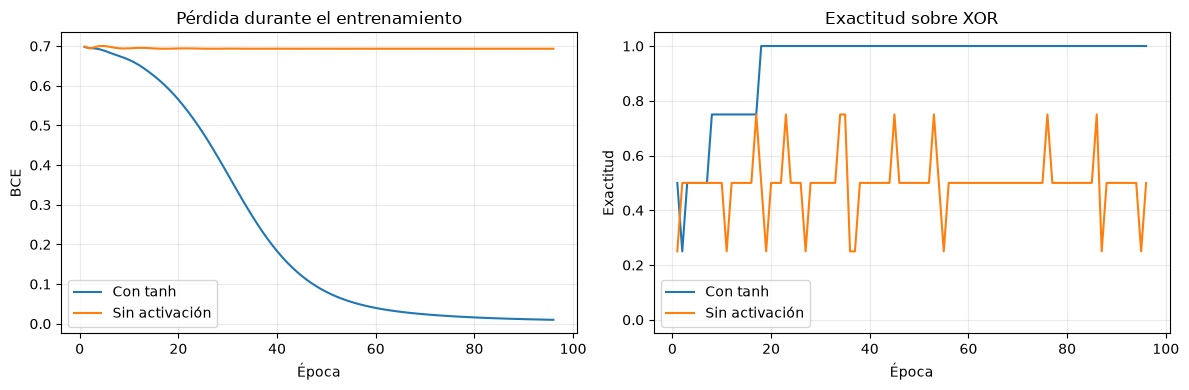

In [6]:
def evaluar(modelo):
    modelo.eval()
    with torch.no_grad():
        probabilidades = torch.sigmoid(modelo(X)).squeeze(1)
        predicciones = (probabilidades >= 0.5).long()
    return probabilidades, predicciones


prob_xor, pred_xor = evaluar(modelo_xor)
prob_lineal, pred_lineal = evaluar(modelo_lineal)
print("Entrada | Real | P(1) tanh | Pred. tanh | P(1) lineal | Pred. lineal")
for i in range(len(X)):
    entrada = tuple(int(v) for v in X[i])
    print(f"{entrada}  |  {int(y[i].item())}   |  {prob_xor[i].item():.6f} |"
          f"     {pred_xor[i].item()}      |   {prob_lineal[i].item():.6f}  |"
          f"      {pred_lineal[i].item()}")

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for nombre, historial in [("Con tanh", historial_xor), ("Sin activación", historial_lineal)]:
    epocas = np.arange(1, len(historial["perdida"]) + 1)
    ejes[0].plot(epocas, historial["perdida"], label=nombre)
    ejes[1].plot(epocas, historial["exactitud"], label=nombre)
ejes[0].set(title="Pérdida durante el entrenamiento", xlabel="Época", ylabel="BCE")
ejes[1].set(title="Exactitud sobre XOR", xlabel="Época", ylabel="Exactitud", ylim=(-0.05, 1.05))
for eje in ejes:
    eje.legend()
    eje.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 1.3. Fronteras de decisión

Los colores representan la probabilidad de la clase 1. La línea negra marca el umbral 0.5 y las etiquetas de los puntos muestran los valores reales de XOR.

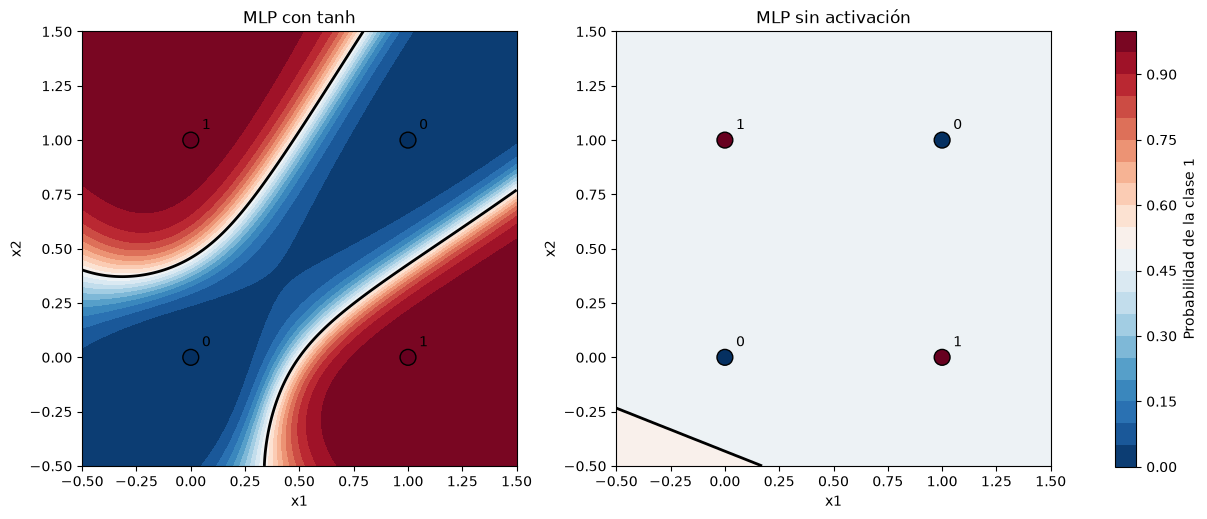

In [7]:
valores = np.linspace(-0.5, 1.5, 250)
xx, yy = np.meshgrid(valores, valores)
malla = torch.tensor(np.column_stack([xx.ravel(), yy.ravel()]), dtype=torch.float32)

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for eje, modelo, titulo in zip(ejes, [modelo_xor, modelo_lineal],
                               ["MLP con tanh", "MLP sin activación"]):
    modelo.eval()
    with torch.no_grad():
        probabilidades = torch.sigmoid(modelo(malla)).numpy().reshape(xx.shape)
    fondo = eje.contourf(xx, yy, probabilidades, levels=np.linspace(0, 1, 21),
                        cmap="RdBu_r", vmin=0, vmax=1)
    if probabilidades.min() < 0.5 < probabilidades.max():
        eje.contour(xx, yy, probabilidades, levels=[0.5], colors="black", linewidths=2)
    else:
        eje.text(0.5, -0.35, "No hay cruce del umbral 0.5", ha="center", fontsize=9)
    eje.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.squeeze(1).numpy(),
                cmap="RdBu_r", vmin=0, vmax=1, edgecolors="black", s=130)
    for entrada, objetivo in zip(X, y):
        eje.annotate(str(int(objetivo.item())),
                     (entrada[0].item(), entrada[1].item()), xytext=(8, 8),
                     textcoords="offset points")
    eje.set(title=titulo, xlabel="x1", ylabel="x2", aspect="equal")
fig.colorbar(fondo, ax=ejes, label="Probabilidad de la clase 1")
plt.show()

### 1.4. Equivalencia de las capas sin activación

Esta celda calcula los pesos y el sesgo de una única capa equivalente y compara sus logits con los de la red sin activación.

In [8]:
modelo_lineal.eval()
with torch.no_grad():
    W1, b1 = modelo_lineal.oculta.weight, modelo_lineal.oculta.bias
    W2, b2 = modelo_lineal.salida.weight, modelo_lineal.salida.bias
    W_equivalente = W2 @ W1
    b_equivalente = W2 @ b1 + b2
    logits_compuestos = modelo_lineal(malla)
    logits_equivalentes = malla @ W_equivalente.T + b_equivalente
    diferencia = (logits_compuestos - logits_equivalentes).abs().max().item()

print("W equivalente:", W_equivalente)
print("b equivalente:", b_equivalente)
print(f"Diferencia absoluta máxima en la malla: {diferencia:.10f}")
print("Composición: W2(W1x + b1) + b2 = (W2W1)x + (W2b1 + b2)")

W equivalente: tensor([[-0.0004, -0.0009]])
b equivalente: tensor([-0.0004])
Diferencia absoluta máxima en la malla: 0.0000000871
Composición: W2(W1x + b1) + b2 = (W2W1)x + (W2b1 + b2)


### 1.5. Red de la diapositiva: 3 → 4 → 4 → 2

Construir la arquitectura y recorrer `named_parameters()` para mostrar la forma y cantidad de elementos de cada tensor de pesos y sesgos.

In [9]:
class RedMulticapa(nn.Module):
    def __init__(self):
        super().__init__()
        self.oculta1 = nn.Linear(3, 4)
        self.oculta2 = nn.Linear(4, 4)
        self.salida = nn.Linear(4, 2)
        self.activacion = nn.Tanh()

    def forward(self, x):
        x = self.activacion(self.oculta1(x))
        x = self.activacion(self.oculta2(x))
        return self.salida(x)


torch.manual_seed(42)
model = RedMulticapa()
print(model)
print(f"\n{'Tensor':<22} {'Forma':<15} {'Parámetros':>10}")
for nombre, parametro in model.named_parameters():
    print(f"{nombre:<22} {str(tuple(parametro.shape)):<15} {parametro.numel():>10}")

total_parametros = sum(p.numel() for p in model.parameters())
total_manual = (3 * 4 + 4) + (4 * 4 + 4) + (4 * 2 + 2)
print(f"\nTotal con PyTorch: {total_parametros}")
print(f"Total manual: (3×4 + 4) + (4×4 + 4) + (4×2 + 2) = {total_manual}")
assert total_parametros == total_manual == 46
print("Forma de salida para un ejemplo:", tuple(model(torch.zeros(1, 3)).shape))

RedMulticapa(
  (oculta1): Linear(in_features=3, out_features=4, bias=True)
  (oculta2): Linear(in_features=4, out_features=4, bias=True)
  (salida): Linear(in_features=4, out_features=2, bias=True)
  (activacion): Tanh()
)

Tensor                 Forma           Parámetros
oculta1.weight         (4, 3)                  12
oculta1.bias           (4,)                     4
oculta2.weight         (4, 4)                  16
oculta2.bias           (4,)                     4
salida.weight          (2, 4)                   8
salida.bias            (2,)                     2

Total con PyTorch: 46
Total manual: (3×4 + 4) + (4×4 + 4) + (4×2 + 2) = 46
Forma de salida para un ejemplo: (1, 2)
